# 02 — Supervised Fine-Tuning (SFT)

**Goal:** turn the domain-aware base model into one that **follows instructions**,
by training on (prompt → response) pairs while **masking the prompt out of the
loss**.

This is stage **2**. Training starts from the CPT adapter (`checkpoints/cpt/`) so
the model already knows the domain, and the result is saved to `checkpoints/sft/`
for DPO.

> Prerequisite: run `01_cpt.ipynb` first to produce `checkpoints/cpt/adapter.pt`.
> (If it's missing, this notebook falls back to the raw base model and warns.)

## The idea: same loss as CPT, but mask the prompt

SFT uses the **exact same** next-token cross-entropy as CPT. The single
conceptual difference is *which tokens count*:

- **CPT:** loss on **all** tokens (`labels == input_ids`).
- **SFT:** loss on **response tokens only**. The label of every *prompt*
  token is set to `-100`, the `ignore_index` that `cross_entropy` skips.

```
prompt tokens                response tokens
[### Instruction: ... ### Response:]  [A lumenwright is ... <eos>]
labels: -100 -100 -100 ...      -100   id   id   id   ...   id
        \___________ ignored ________/  \____ trained on ____/
```

Why mask? The model should not be trained to *generate the prompt* — only to
learn the mapping prompt → response. Masking focuses all gradient signal on the
part that should actually be produced.

The masking is built in `SFTDataset` (`src/data.py`); below, a `labels`
tensor is printed to show the `-100`s explicitly.

In [1]:
import sys, pathlib
from functools import partial

REPO_ROOT = pathlib.Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.utils import (set_seed, get_device, amp_context, LossLogger,
                       plot_curves, read_jsonl, save_lora_checkpoint,
                       load_lora_checkpoint)
from src.lora import inject_lora, lora_parameters, count_parameters
from src.losses import causal_lm_loss
from src.data import SFTDataset, pad_collate, format_prompt

set_seed(42)
device = get_device()
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M"
DATA_DIR = REPO_ROOT / "data"
CKPT_DIR = REPO_ROOT / "checkpoints"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
inject_lora(model, target_modules=("q_proj", "v_proj"), r=8, alpha=16)
model.to(device)

# Chained pipeline: start from the CPT adapter if available.
cpt_ckpt = CKPT_DIR / "cpt" / "adapter.pt"
if cpt_ckpt.exists():
    meta = load_lora_checkpoint(model, cpt_ckpt, map_location=device)
    print("Loaded CPT adapter:", meta)
else:
    print("WARNING: no CPT adapter found; starting from the raw base model.")

trainable, total = count_parameters(model)
print(f"Device: {device} | trainable {trainable:,} / {total:,}")

/Users/jorgesandoval/code/llm-post-training-from-scratch/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Loaded CPT adapter: {'stage': 'cpt', 'epochs': 40, 'lr': 0.0003, 'block_size': 128, 'final_loss': 1.7247185707092285}
Device: mps | trainable 460,800 / 134,975,808


## Build the SFT dataset and inspect the masking

Loads `data/sft_pairs.jsonl`, wraps it in `SFTDataset`, and prints one example's
`labels` next to its tokens so the `-100` prompt mask is visible. Variable-length
sequences are right-padded by `pad_collate` (padding labels with `-100` too).

In [2]:
BATCH_SIZE = 4

pairs = read_jsonl(DATA_DIR / "sft_pairs.jsonl")
dataset = SFTDataset(pairs, tokenizer, max_len=512)
collate = partial(pad_collate, pad_token_id=tokenizer.pad_token_id)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)

print(f"SFT pairs: {len(dataset)}")

ex = dataset[0]
toks = tokenizer.convert_ids_to_tokens(ex["input_ids"])
print("\ntoken | label   (-100 = masked prompt token)")
for tok, lab in list(zip(toks, ex["labels"].tolist()))[:24]:
    print(f"  {tok!r:>14}  ->  {lab}")
n_masked = (ex["labels"] == -100).sum().item()
print(f"\nmasked (prompt) tokens: {n_masked} / {len(ex['labels'])}")

SFT pairs: 50

token | label   (-100 = masked prompt token)
           '###'  ->  -100
  'ĠInstruction'  ->  -100
             ':'  ->  -100
             'Ċ'  ->  -100
          'What'  ->  -100
           'Ġis'  ->  -100
            'Ġa'  ->  -100
            'Ġl'  ->  -100
          'umen'  ->  -100
        'wright'  ->  -100
             '?'  ->  -100
             'Ċ'  ->  -100
             'Ċ'  ->  -100
           '###'  ->  -100
     'ĠResponse'  ->  -100
             ':'  ->  -100
             'Ċ'  ->  -100
             'A'  ->  49
            'Ġl'  ->  303
          'umen'  ->  17065
        'wright'  ->  26557
           'Ġis'  ->  314
           'Ġan'  ->  354
      'Ġartisan'  ->  32958

masked (prompt) tokens: 17 / 59


## Capture "before" behavior

Shows how the model (post-CPT, pre-SFT) responds to an instruction in the
prompt format. It typically rambles or continues the prompt rather than giving a
clean answer — exactly what SFT will fix.

In [3]:
@torch.no_grad()
def answer(model, instruction, max_new_tokens=60):
    model.eval()
    prompt = format_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:],
                            skip_special_tokens=True).strip()


PROBE_INSTRUCTIONS = [
    "What is a lumenwright?",
    "What should I do if my lumen is fretting?",
    "Name the three grades of lumen by brightness.",
]
before = {q: answer(model, q) for q in PROBE_INSTRUCTIONS}
for q, a in before.items():
    print(f"Q: {q}\n  -> {a}\n")

Q: What is a lumenwright?
  -> A lumenwright is a lumenmaster. A master lumenwright is called a master-sparke.

Q: What should I do if my lumen is fretting?
  -> Ask the master to see if the tension is right. Then the master may adjust the key.

Q: Name the three grades of lumen by brightness.
  -> The name of the lumen is inscribed in a deadstone that the keeper may read.



## Training loop

Identical in shape to the CPT loop — the difference is entirely in the data: the
`labels` already carry `-100` on prompt tokens, so `causal_lm_loss` automatically
trains only on responses. The real `attention_mask` from `pad_collate` is also
passed so padding is ignored.

In [4]:
EPOCHS = 30
LR = 2e-4

optimizer = torch.optim.AdamW(lora_parameters(model), lr=LR)
logger = LossLogger()

model.train()
step = 0
for epoch in range(EPOCHS):
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attn = batch["attention_mask"].to(device)

        with amp_context(device):
            logits = model(input_ids=input_ids, attention_mask=attn).logits
            loss = causal_lm_loss(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_parameters(model), 1.0)
        optimizer.step()

        logger.log(step, loss=loss.item())
        step += 1
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d} | step {step:4d} | loss {loss.item():.4f}")

print(f"\nFinal loss: {logger.last('loss'):.4f}")

epoch   0 | step   13 | loss 3.6751


epoch   5 | step   78 | loss 2.6490


epoch  10 | step  143 | loss 1.7049


epoch  15 | step  208 | loss 1.5355


epoch  20 | step  273 | loss 1.2595


epoch  25 | step  338 | loss 0.8430


epoch  29 | step  390 | loss 0.8514

Final loss: 0.8514


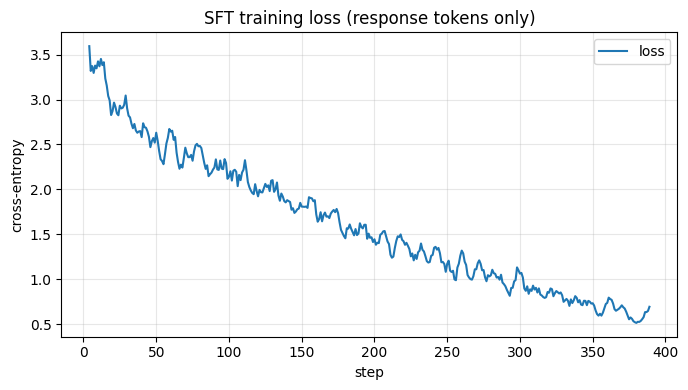

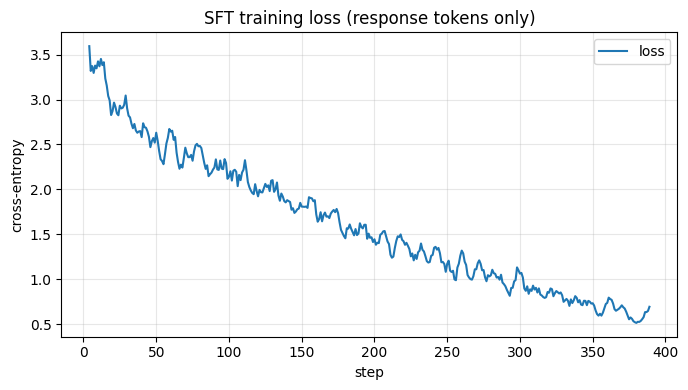

In [5]:
fig = plot_curves(logger, ["loss"], title="SFT training loss (response tokens only)",
                  ylabel="cross-entropy", smooth=5)
fig

## Before vs after: instruction following

After SFT the model should answer the instruction directly and concisely in the
response format, using the domain knowledge from CPT.

In [6]:
after = {q: answer(model, q) for q in PROBE_INSTRUCTIONS}
for q in PROBE_INSTRUCTIONS:
    print(f"Q: {q}")
    print(f"  BEFORE (post-CPT): {before[q]}")
    print(f"  AFTER  (post-SFT): {after[q]}\n")

Q: What is a lumenwright?
  BEFORE (post-CPT): A lumenwright is a lumenmaster. A master lumenwright is called a master-sparke.
  AFTER  (post-SFT): A lumenwright is an apprentice shoemaker. A lumenwright is an educator. A lumenmaster learns craftsmanship before starting a journey. A lumenwrights hope one day they'll be able to see the light.

Q: What should I do if my lumen is fretting?
  BEFORE (post-CPT): Ask the master to see if the tension is right. Then the master may adjust the key.
  AFTER  (post-SFT): Your lumen is fretting because its resonating too much, not from a bad mother-grat. It can be fixed by adjusting its resting tissue.

Q: Name the three grades of lumen by brightness.
  BEFORE (post-CPT): The name of the lumen is inscribed in a deadstone that the keeper may read.
  AFTER  (post-SFT): The three grades are the lumen called entirely alone, called alone-sung, and kept from joining, for the rest, the joy of Alexandria; bysheskindling from thesaugusfromthesurgrainingfrom

In [7]:
ckpt_path = save_lora_checkpoint(
    model, CKPT_DIR / "sft" / "adapter.pt",
    metadata={"stage": "sft", "epochs": EPOCHS, "lr": LR,
              "final_loss": logger.last("loss")},
)
print("Saved:", ckpt_path)

Saved: /Users/jorgesandoval/code/llm-post-training-from-scratch/checkpoints/sft/adapter.pt


## Recap & what's next

- Used the **same loss as CPT** but **masked the prompt** with `-100`, so only
  response tokens were trained.
- The model now **follows instructions** in the format, grounded in domain
  knowledge from CPT.
- Saved the adapter to `checkpoints/sft/adapter.pt`.

The model is now helpful, but not yet *aligned to preferences* — it may produce
mediocre or off-tone answers it has no reason to avoid.

➡️ **`03_dpo.ipynb`** — Direct Preference Optimization: using (chosen, rejected)
pairs and a **frozen copy of this SFT model as the reference**, the model is
taught to prefer better answers — with no reward model.